## 1. Import Libraries & Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
rng = np.random.default_rng(42)

## 2. Load the Dataset

In [4]:
data_train = pd.read_csv("mnist_train.csv")
data_test = pd.read_csv("mnist_test.csv")

## 3. Convert DataFrames to NumPy Arrays

In [5]:
data_train = data_train.to_numpy()
data_test = data_test.to_numpy()

In [6]:
data_train.shape

(60000, 785)

In [7]:
data_test.shape

(10000, 785)

## 5. Feature and Target Splitting ($X$ / $y$ Split)

In [8]:
X_train = data_train[:,1:]
y_train = data_train[:,0]
X_test = data_test[:,1:]
y_test = data_test[:,0]

## 6. Data Visualization & Sample Inspection

In [9]:
first_image = data_train[0][1:].reshape(28,28)
data_train[0][0]

np.int64(5)

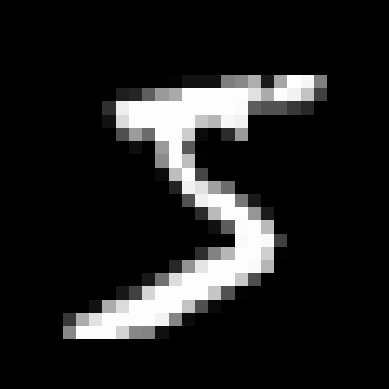

In [10]:
plt.imshow(first_image, cmap='gray')
plt.axis('off')
plt.show()

## resape

In [11]:
X_train = X_train.reshape(-1,1,28,28)
X_test = X_test.reshape(-1,1,28,28)

In [12]:
X_train.shape

(60000, 1, 28, 28)

## Zero-center

In [13]:
mean_image = np.mean(X_test,axis=0)
X_train = X_train - mean_image
X_test = X_test - mean_image

## ReLU

In [14]:
def relu(x):
    return np.maximum(0,x)

## Padding

In [15]:
def padding(x,pad = 1):

    num_row = x.shape[2]
    num_column = x.shape[3]

    new_column = num_column + 2*pad
    new_row = num_row + 2*pad

    zeros = np.zeros((x.shape[0],1,new_row,new_column))
    print(zeros.shape)
    for i in range(x.shape[0]):
        zeros[i,0,pad:pad+num_row,pad:pad + num_column] = x[i,0]

    return zeros

In [16]:
def padding_with_numpy(x,pad = 1):
    return np.pad(x,((0,0),(0,0),(pad,pad),(pad,pad)),mode='constant',constant_values=0)

In [17]:
matrix_test = np.arange(24000).reshape(60,1,20,20)

In [18]:
ft = np.array([[0,1,0],
                  [0,1,0],
                  [0,1,0]])


In [19]:
ft

array([[0, 1, 0],
       [0, 1, 0],
       [0, 1, 0]])

In [20]:
matrix_test.shape

(60, 1, 20, 20)

### vanilla convolution

In [21]:
def vanilla_conv(x,filters,stride =1):

    out_row = int(np.floor((x.shape[2]-filters.shape[0])/stride) + 1)
    out_col = int(np.floor((x.shape[3]-filters.shape[0])/stride) + 1)
    empty = np.zeros((x.shape[0],x.shape[1],out_row,out_col))
    for i in range(x.shape[0]):
        for j in range(out_row):
            for k in range(out_col):
                empty[i,0,j,k] = np.einsum('ij,ij->',x[i,0,j:j+filters.shape[0],k:k+filters.shape[0]],filters)

    return empty

 ### vanilla max Pooling

In [22]:
def vanilla_maxpool(max_pool_input,size_filter = 2 ,stride = 1):

    row_size = max_pool_input.shape[2]
    output_size = int((row_size - size_filter)//stride) +1
    output_maxpool = np.zeros((max_pool_input.shape[0],1,output_size,output_size))

    for i in range(max_pool_input.shape[0]):
        for j in range(output_size):
            for k in range(output_size):
                h_start = j * stride
                v_start = k * stride
                output_maxpool[i,0,j,k] = np.max(max_pool_input[i,0,h_start:h_start+size_filter,v_start:v_start+size_filter])
    return output_maxpool

## im2col

### convolution with im2col

In [23]:
def convolution(input_conv, filters, stride =1):
    number_of_input = input_conv.shape[0]
    number_of_row = input_conv.shape[2]
    size_filter = filters.shape[0]

    output_size = int((number_of_row - size_filter)//stride + 1)

    temp_matrix = np.zeros((number_of_input , size_filter ** 2 , output_size ** 2))

    for i in range( number_of_input):

        for j in range(output_size):
            for k in range(output_size):

                h_start = j * stride
                v_start = k * stride

                temp_matrix[i,:,j * output_size + k] = (input_conv[
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ].flatten())

    output_conv = ((np.expand_dims(filters.flatten(),axis=0))@temp_matrix).reshape(number_of_input,1 ,output_size,output_size)


    return output_conv

### conv backward

In [ ]:
def convolution_backward(input_conv_back, input_dloss_z,w_l,stride):
    number_of_input = input_conv_back.shape[0]
    number_of_row = input_conv_back.shape[2]
    size_dloss_z = input_dloss_z.shape[2]
    
    size_w_l = w_l.shape[2]
    # output_size = int((number_of_row - size_filter)//stride + 1)
    output_conv = np.zeros_like(input_conv_back)


    for i in range( number_of_input):
        for j in range(size_dloss_z):
            for k in range(size_dloss_z):

                h_start = j * stride
                v_start = k * stride

                output_conv[
                i,
                0,
                h_start : h_start + size_w_l,
                v_start : v_start + size_w_l ] += input_dloss_z[i,0,j,k] * w_l[i]

    return output_conv

### conv fo backward

In [ ]:
def convolution_backward(input_conv_back, filters, stride):
    number_of_input = input_conv_back.shape[0]
    number_of_row = input_conv_back.shape[2]
    size_filter = filters.shape[0]

    output_size = int((number_of_row - size_filter)//stride + 1)

    temp_matrix = np.zeros((number_of_input , size_filter ** 2 , output_size ** 2))
    print(temp_matrix.shape)

    for i in range( number_of_input):

        for j in range(output_size):
            for k in range(output_size):

                h_start = j * stride
                v_start = k * stride

                temp_matrix[i,:,j * output_size + k] = (input_conv_back [
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ].flatten())

    output_conv = ((np.expand_dims(filters.flatten(),axis=0))@temp_matrix).reshape(number_of_input,1 ,output_size,output_size)


    return output_conv

### max pooling

In [24]:
def max_pooling(input_maxpool,size_filter = 2,stride =2):
    mask = np.zeros_like(input_maxpool)
    number_of_input = input_maxpool.shape[0]
    number_of_row = input_maxpool.shape[2]
    size_filter = size_filter

    output_size = int((number_of_row - size_filter)//stride + 1)

    temp_matrix = np.zeros((number_of_input , size_filter ** 2 , output_size ** 2))

    for i in range( number_of_input):
        for j in range(output_size):
            for k in range(output_size):

                h_start = j * stride
                v_start = k * stride

                temp_matrix[i,:,j * output_size + k] = (input_maxpool[
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ].flatten())

                r,c =np.unravel_index(np.argmax(input_maxpool[
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ].flatten()),(size_filter,size_filter))
                mask[i,0,h_start + r,v_start +c] = 1

    output_maxpool = ((np.max(temp_matrix,axis=1)).reshape(number_of_input,1 ,output_size,output_size))

    return output_maxpool , mask

### max pool backward

In [ ]:
def max_pool_backward(input_max_back,size_filter,stride,dloss_in, mask):
    number_of_input = input_max_back.shape[0]
    number_of_row = input_max_back.shape[2]
    size_filter = size_filter

    output_size = int((number_of_row - size_filter)//stride + 1)

    temp_matrix = np.ones_like(input_max_back)

    for i in range( number_of_input):
        for j in range(output_size):
            for k in range(output_size):

                h_start = j * stride
                v_start = k * stride

                temp_matrix[
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ] = (mask[
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ]) * dloss_in[i,:,j,k]

    return temp_matrix


## avg pooling

In [25]:
def avg_pooling(input_avg,size_filter = 2,stride =2):
    number_of_input = input_avg.shape[0]
    number_of_row = input_avg.shape[2]
    size_filter = size_filter

    output_size = int((number_of_row - size_filter)//stride + 1)

    temp_matrix = np.zeros((number_of_input , size_filter ** 2 , output_size ** 2))

    for i in range( number_of_input):
        for j in range(output_size):
            for k in range(output_size):

                h_start = j * stride
                v_start = k * stride

                temp_matrix[i,:,j * output_size + k] = (input_avg[
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ].flatten())

    output_avg_pooling = ((np.average(temp_matrix,axis=1)).reshape(number_of_input,1 ,output_size,output_size))


    return output_avg_pooling

### avg_pool_backward

In [ ]:
def avg_pool_backward(input_avg_back,size_filter,stride,dloss_in):
    number_of_input = input_avg_back.shape[0]
    number_of_row = input_avg_back.shape[2]
    size_filter = size_filter

    output_size = int((number_of_row - size_filter)//stride + 1)

    temp_matrix = np.zeros_like(input_avg_back)

    for i in range( number_of_input):
        for j in range(output_size):
            for k in range(output_size):

                h_start = j * stride
                v_start = k * stride

                temp_matrix[
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ] = (temp_matrix[
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ]) + ((1/ size_filter ** 2) * dloss_in[i,:,j,k])

    return temp_matrix


## activation

In [26]:
def relu(x):
    return np.maximum(0,x)

In [27]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

## initialization

In [28]:
def xavier_init(shape):

    """
    برای لایه دنس: shape = (input_dim, output_dim)
    برای لایه کانو: shape = (num_filters, in_channels, height, width)
    """
    if len(shape) == 2:
        fan_in = shape[0]
    elif len(shape) == 4:
        fan_in = shape[1] * shape[2] * shape[3]
    else:
        raise ValueError("xavier_init_error")

    std = np.sqrt(1 / fan_in)
    return rng.normal(0,std, size = shape)

تله‌ی مخفی نامپای (بحرانی): اگر شبکه عصبی تو در یک تکرار (Epoch) به قدری اشتباه پیش‌بینی کند که احتمال یک کلاس را دقیقاً 0.0 تشخیص دهد، دستور np.log(0) مقدار -inf (منفی بی‌نهایت) را تولید می‌کند! ضرب این مقدار در برچسب‌ها باعث می‌شود کل خروجی لغزش کند و به عدد NaN (مخفف Not a Number) تبدیل شود و کل شبکه عصبی‌ات نابود شود.

In [29]:
def he_init(shape):
    """
    برای لایه دنس: shape = (input_dim, output_dim)
    برای لایه کانو: shape = (num_filters, in_channels, height, width)
    """
    if len(shape) == 2:
        fan_in = shape[0]
    elif len(shape) == 4:
        fan_in = shape[1] * shape[2] * shape[3]
    else:
        raise ValueError("he_init_error")

    std = np.sqrt(2 / fan_in)
    return rng.normal(0,std,size=shape)


## Cross entropy loss

In [1]:
class neural_networks():
    def __init__(self,input_dim,output_dim,layer_sizes,conv_list,activation = sigmoid,initialize_weights = True):
        self.weights = [] # وزن های لایه های fc
        self.biases = [] # بایاس های لایه fc
        self.biases_conv = [] # بایاس های لایه های cnn
        self.filter_list = [] # فیلترها (کرنل ها) های لایه های cnn
        self.fc_z_catche = [] # برای ذخیره ورودی خام (z = wx +b)برای لایه fc
        self.fc_a_catche = [] # برای ذخیره خروجی اکتیویشن (a = f(z برای لایه fc
        self.conv_z_catche = [] # برای ذخیره ورودی خام (z = wx +b) برای لایه کانولوشن
        self.conv_a_catche = [] # برای ذخیره خروجی اکتیویشن (a = f(z برای لایه کانولوشن
        self.dloss_w_fc = [] # نگهداری مشتق loss نسبت به z
        self.dloss_b_fc = [] # نگهداری مشتق loss نسبت به bias
        self.mask_maxpool= [] # نگهداری ماتریس ماسک ، برای نگهداری اندیس عنصر ماسک روی هر فیلتر

        self.is_first_forward = True
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layer_sizes = layer_sizes
        self.initialize_weights = initialize_weights
        self.activation = activation
        self.conv_list = conv_list

    def initialize_weights(self,flag):
        current_layer = self.input_dim

        for i in range(len(self.layer_sizes)):
            if flag and self.activation == "sigmoid":
                self.weights.append(xavier_init((current_layer , self.layer_sizes[i])))
            elif flag and self.activation == "relu":
                self.weights.append(he_init((current_layer , self.layer_sizes[i])))
            else:
                self.weights.append(rng.normal(0,1,size=(current_layer , self.layer_sizes[i])))

            self.biases.append(np.zeros((self.layer_sizes[i],1)))
            current_layer = self.layer_sizes[i]


    def forward(self,x):
        number_of_conv = -1 # شماره لایه های کانولوشن هست که می خواهیم داشته باشیم که موقع اعمال کانولوشن به مشکل نخوریم
        current_input= x

        if self.activation == "sigmoid": # تعیین نوع اکتیوشن برای اعمال و مقدار دهی های اولی
            activation = sigmoid
        elif self.activation == "relu":
            activation = relu



        for i in range(len(self.conv_list)): # تعیین نوع ورودی لیست کانولوشن
            if self.conv_list[i][0] == "maxpool" :
                current_input,mask = max_pooling(current_input
                                            ,self.conv_list[i][1]
                                            ,self.conv_list[i][2])

                self.mask_maxpool.append(mask)
                self.conv_a_catche.append(current_input)

            elif self.conv_list[i][0] == "avgpool" :
                current_input = avg_pooling(current_input,
                                            self.conv_list[i][1],
                                            self.conv_list[i][2])

                self.conv_a_catche.append(current_input)

            elif self.conv_list[i][0] == "conv" :

                number_of_conv +=1

                if self.is_first_forward:

                    if self.activation == "sigmoid": # اینا فیلتر ها را ایجاد کردم برای کانو
                        self.filter_list.append(xavier_init((self.conv_list[i][1],
                                                             current_input.shape[1],self.conv_list[i][2],
                                                             self.conv_list[i][2])))

                        self.biases_conv.append(np.zeros((1,self.conv_list[i][1])))

                    elif self.activation == "relu":
                        self.filter_list.append(he_init((self.conv_list[i][1],
                                                         current_input.shape[1],
                                                         self.conv_list[i][2],
                                                         self.conv_list[i][2])))

                        self.biases_conv.append(np.zeros((1,self.conv_list[i][1])))


                z = convolution(current_input,self.filter_list[number_of_conv]) +self.biases_conv[number_of_conv]
                self.conv_z_catche.append(z)
                a = activation(z)
                self.conv_a_catche.append(a)
                current_input = a
            else:
                raise ValueError("layer Error")


        self.is_first_forward = False

        current_input = current_input.reshape(-1,self.input_dim) # رابط لایه کانولوشن به لایه دنس

        for i in range(len(self.layer_sizes)-1):

            z = current_input @ self.weights[i] + self.biases[i].T
            self.fc_z_catche.append(z)
            a = activation(z)
            self.fc_a_catche.append(a)
            current_input = a

        z = current_input @ self.weights[-1]+ self.biases[-1].T
        a = activation(z)
        return a

    def backward(self,y_target):
        #ارایه برای نگه داری مشتق های لایه های fc
        dloss_a_fc = [0] * (len(self.weights))
        dloss_z_fc = [0] * (len(self.weights))

        self.dloss_w_fc = [0] * len(self.weights)
        self.dloss_b_fc = [0] * len(self.weights)

        #ارایه برای نگه داری مشتق های لایه های conv

        dloss_a_conv = [0] * (len(self.conv_list))
        dloss_z_conv = [0] * (len(self.conv_list))

        self.dloss_w_conv = [0] * len(self.conv_list)
        self.dloss_b_conv = [0] * len(self.conv_list)




        dloss_a_fc[-1] = - y_target /self.fc_a_catche[-1]
        # پیاده سازی بک پراپ برای fc
        for i in reversed(range(len(self.weights))):


            if self.activation == "sigmoid":
                dloss_z_fc[i] = dloss_a_fc[i] * (self.fc_a_catche[i] * (1-self.fc_a_catche[i]))
            elif self.activation == "relu":
                dloss_z_fc[i] = dloss_a_fc[i] * (self.dloss_z[i] > 0).astype(int)


            self.dloss_w_fc[i] = np.einsum('ij,jk->ik',(self.conv_a_catche[i-1]).T,dloss_z_fc[i])
            if i >= 1:
                dloss_a_fc[i-1] = np.einsum('ij,jk->ik',dloss_z_fc[i],(self.weights[i]).T)




        # انتقال گرادیان لایه اول fc به لایه اخر قسمت کانولوشن
        dloss_a_conv[-1] = dloss_a_fc[0].reshape(self.conv_list[2],self.conv_list[2])
        # پیاده سازی بک پراپ برای لایه conv , maxpool , avgpool
        for l in reversed(range(len(self.conv_list))):
            if self.conv_list[l][0] == "maxpool" :
                ...
            elif self.conv_list[l][0] == "avgpool" :
                ...
            elif self.conv_list[l][0] == "conv" :
                dloss_z_conv[l] = convolution(self.conv_a_catche[l],dloss_a_conv[l],self.conv_list[3])
                if l >= 1 :
                    dloss_a_conv[l-1] = ...
                    temp_a = np.zeros_like(self.conv_a_catche[l])







    def update(self):
        ...

    def train(self):
        ...

NameError: name 'sigmoid' is not defined

# class neural network

In [31]:
class neural_networks():
    def __init__(self,input_dim,output_dim,layer_sizes,conv_list,activation = sigmoid,initialize_weights = True):
        self.weights = [] # وزن های لایه های fc
        self.biases = [] # بایاس های لایه fc
        self.biases_conv = [] # بایاس های لایه های cnn
        self.filter_list = [] # فیلترها (کرنل ها) های لایه های cnn
        self.fc_z_catche = [] # برای ذخیره ورودی خام (z = wx +b)برای لایه fc
        self.fc_a_catche = [] # برای ذخیره خروجی اکتیویشن (a = f(z برای لایه fc
        self.conv_z_catche = [] # برای ذخیره ورودی خام (z = wx +b) برای لایه کانولوشن
        self.conv_a_catche = [] # برای ذخیره خروجی اکتیویشن (a = f(z برای لایه کانولوشن
        self.dloss_w_fc = [] # نگهداری مشتق loss نسبت به z
        self.dloss_b_fc = [] # نگهداری مشتق loss نسبت به bias
        self.mask_maxpool= [] # نگهداری ماتریس ماسک ، برای نگهداری اندیس عنصر ماسک روی هر فیلتر

        self.is_first_forward = True
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layer_sizes = layer_sizes
        self.initialize_weights = initialize_weights
        self.activation = activation
        self.conv_list = conv_list

    def initialize_weights(self,flag):
        current_layer = self.input_dim

        for i in range(len(self.layer_sizes)):
            if flag and self.activation == "sigmoid":
                self.weights.append(xavier_init((current_layer , self.layer_sizes[i])))
            elif flag and self.activation == "relu":
                self.weights.append(he_init((current_layer , self.layer_sizes[i])))
            else:
                self.weights.append(rng.normal(0,1,size=(current_layer , self.layer_sizes[i])))

            self.biases.append(np.zeros((self.layer_sizes[i],1)))
            current_layer = self.layer_sizes[i]


    def forward(self,x):
        number_of_conv = -1 # شماره لایه های کانولوشن هست که می خواهیم داشته باشیم که موقع اعمال کانولوشن به مشکل نخوریم
        current_input= x

        if self.activation == "sigmoid": # تعیین نوع اکتیوشن برای اعمال و مقدار دهی های اولی
            activation = sigmoid
        elif self.activation == "relu":
            activation = relu



        for i in range(len(self.conv_list)): # تعیین نوع ورودی لیست کانولوشن
            if self.conv_list[i][0] == "maxpool" :
                current_input,mask = max_pooling(current_input
                                            ,self.conv_list[i][1]
                                            ,self.conv_list[i][2])

                self.mask_maxpool.append(mask)
                self.conv_a_catche.append(current_input)

            elif self.conv_list[i][0] == "avgpool" :
                current_input = avg_pooling(current_input,
                                            self.conv_list[i][1],
                                            self.conv_list[i][2])

                self.conv_a_catche.append(current_input)

            elif self.conv_list[i][0] == "conv" :

                number_of_conv +=1

                if self.is_first_forward:

                    if self.activation == "sigmoid": # اینا فیلتر ها را ایجاد کردم برای کانو
                        self.filter_list.append(xavier_init((self.conv_list[i][1],
                                                             current_input.shape[1],self.conv_list[i][2],
                                                             self.conv_list[i][2])))

                        self.biases_conv.append(np.zeros((1,self.conv_list[i][1])))

                    elif self.activation == "relu":
                        self.filter_list.append(he_init((self.conv_list[i][1],
                                                         current_input.shape[1],
                                                         self.conv_list[i][2],
                                                         self.conv_list[i][2])))

                        self.biases_conv.append(np.zeros((1,self.conv_list[i][1])))


                z = convolution(current_input,self.filter_list[number_of_conv]) +self.biases_conv[number_of_conv]
                self.conv_z_catche.append(z)
                a = activation(z)
                self.conv_a_catche.append(a)
                current_input = a
            else:
                raise ValueError("layer Error")


        self.is_first_forward = False

        current_input = current_input.reshape(-1,self.input_dim) # رابط لایه کانولوشن به لایه دنس

        for i in range(len(self.layer_sizes)-1):

            z = current_input @ self.weights[i] + self.biases[i].T
            self.fc_z_catche.append(z)
            a = activation(z)
            self.fc_a_catche.append(a)
            current_input = a

        z = current_input @ self.weights[-1]+ self.biases[-1].T
        a = activation(z)
        return a

    def backward(self,y_target):
        #ارایه برای نگه داری مشتق های لایه های fc
        dloss_a_fc = [0] * (len(self.weights))
        dloss_z_fc = [0] * (len(self.weights))

        self.dloss_w_fc = [0] * len(self.weights)
        self.dloss_b_fc = [0] * len(self.weights)

        #ارایه برای نگه داری مشتق های لایه های conv

        dloss_a_conv = [0] * (len(self.conv_list))
        dloss_z_conv = [0] * (len(self.conv_list))

        self.dloss_w_conv = [0] * len(self.conv_list)
        self.dloss_b_conv = [0] * len(self.conv_list)




        dloss_a_fc[-1] = - y_target /self.fc_a_catche[-1]
        # پیاده سازی بک پراپ برای fc
        for i in reversed(range(len(self.weights))):


            if self.activation == "sigmoid":
                dloss_z_fc[i] = dloss_a_fc[i] * (self.fc_a_catche[i] * (1-self.fc_a_catche[i]))
            elif self.activation == "relu":
                dloss_z_fc[i] = dloss_a_fc[i] * (self.dloss_z[i] > 0).astype(int)


            self.dloss_w_fc[i] = np.einsum('ij,jk->ik',(self.conv_a_catche[i-1]).T,dloss_z_fc[i])
            if i >= 1:
                dloss_a_fc[i-1] = np.einsum('ij,jk->ik',dloss_z_fc[i],(self.weights[i]).T)




        # انتقال گرادیان لایه اول fc به لایه اخر قسمت کانولوشن
        dloss_a_conv[-1] = dloss_a_fc[0]
        # پیاده سازی بک پراپ برای لایه conv , maxpool , avgpool
        for l in reversed(range(len(self.conv_list))):
            if self.conv_list[l][0] == "maxpool" :
                ...
            elif self.conv_list[l][0] == "avgpool" :
                ...
            elif self.conv_list[l][0] == "conv" :
                dloss_z_conv[l] = convolution_backward(self.)






    def update(self):
        ...

    def train(self):
        ...